In [51]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "bioGraph").is_dir():
    raise FileNotFoundError("Start Jupyter from the repository root or notebooks directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm

from bioGraph.data.loading import load_disease_genes, load_ppi_graph
from bioGraph.data.splitting import split_disease_genes, split_known_genes
from bioGraph.methods.ranking import (
    qa_score,
    
    dk_score,
    rwr_score,
    diamond_score,
    neighbourhood_score,
    )
from bioGraph.evaluation.metrics import average_precision_at_k, recall_at_k
from bioGraph.methods.utils import scores_to_ranking
from bioGraph import sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
data_dir = project_root / "data" / "raw"
results_dir = project_root / "outputs" / "results"
reports_dir = project_root / "outputs" / "reports"
results_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
ppi_path = data_dir / "PPI202207.txt"
disease_path = data_dir / "pcbi.1004120.s004.txt"

Ggen = load_ppi_graph(ppi_path)
diseases = load_disease_genes(disease_path)
basis = sim.precompute_basis_matrices(Ggen)
nodelist = basis.nodelist
A_sparse = basis.adjacency
L = basis.laplacian
R = basis.normalized_adjacency


print(
    f"Loaded Ggen with {Ggen.number_of_nodes():,} nodes and "
    f"{Ggen.number_of_edges():,} undirected edges."
)
print(f"Average coordination number: {2 * Ggen.number_of_edges() / Ggen.number_of_nodes():.2f}")

print(f"Loaded diseases for {len(diseases)} diseases.")
print(f"Average number of genes per disease: {np.mean([len(genes) for genes in diseases.values()]):.2f}")
print(f"Example: alzheimer disease has {len(diseases['breast neoplasms'])} genes.")


Loaded Ggen with 17,504 nodes and 354,647 undirected edges.
Average coordination number: 40.52
Loaded diseases for 70 diseases.
Average number of genes per disease: 40.61
Example: alzheimer disease has 40 genes.


In [35]:
# Example:
disease_name = "breast neoplasms"#"nutritional and metabolic diseases"#"cardiomyopathies"#"breast neoplasms"
known_genes = sorted(set(diseases[disease_name]) & set(Ggen))
outer_split = split_known_genes(known_genes, train_fraction=0.75, random_state=0)
train_genes = outer_split["train_genes"]
test_genes = outer_split["test_genes"]
print(f"Train: {len(train_genes)} genes")
print(f"Test: {len(test_genes)} genes")

Train: 30 genes
Test: 10 genes


In [ ]:
n = len(nodelist)

# Hyperparameters (updated)
qa_t = 0.45
qa_diag = 5
dk_t = 0.3
rwr_return_prob = 0.4
diamond_alpha = 9
diamond_number_to_rank = 300

#running times
# RWR ~ NBR  << DK  < DIAMOND ~ QA

# Run each method directly from bioGraph.methods.ranking.
qa_scores = qa_score(Ggen, train_genes, t=qa_t, H=A_sparse.copy(), diag=qa_diag, nodelist=nodelist)
dk_scores = dk_score(Ggen, train_genes, t=dk_t, L=L, nodelist=nodelist)
rwr_scores = rwr_score(
    Ggen,
    train_genes,
    normalized_adjacency=R,
    return_prob=rwr_return_prob,
    nodelist=nodelist,
)
diamond_scores = diamond_score(
    Ggen,
    train_genes,
    A=A_sparse,
    alpha=diamond_alpha,
    number_to_rank=diamond_number_to_rank,
    nodelist=nodelist,
)
neighbourhood_scores = neighbourhood_score(
    Ggen,
    train_genes,
    A=A_sparse,
    nodelist=nodelist,
    weighted="absolute",
)

rankings = {
    "qa_score": scores_to_ranking(qa_scores, nodelist, Ggen, train_genes),
    "dk_score": scores_to_ranking(dk_scores, nodelist, Ggen, train_genes),
    "rwr_score": scores_to_ranking(rwr_scores, nodelist, Ggen, train_genes),
    "diamond_score": scores_to_ranking(diamond_scores, nodelist, Ggen, train_genes),
    "neighbourhood_score": scores_to_ranking(neighbourhood_scores, nodelist, Ggen, train_genes),
}

k_values = [5, 10, 20]

print(f"n={n} | Train genes: {len(train_genes)} | Test genes: {len(test_genes)}")
print("\n=== Benchmark results on current test set ===")
for method_name, ranking in rankings.items():
    print(f"\nMethod: {method_name}")
    for k in k_values:
        ap = average_precision_at_k(ranking, test_genes, k=k)
        rec = recall_at_k(ranking, test_genes, k=k)
        print(f"K={k:>3} | AP@K={ap:.4f} | Recall@K={rec:.4f}")

    ap_all = average_precision_at_k(ranking, test_genes, k=len(ranking))
    rec_all = recall_at_k(ranking, test_genes, k=len(ranking))
    print(f"K=ALL | AP@All={ap_all:.4f} | Recall@All={rec_all:.4f}")

    top5 = ranking[:5]
    top5_hits = [row for row in top5 if row["gene_id"] in set(test_genes)]
    print("Top 5 predictions:")
    for row in top5:
        print(row)
    print(f"Top-5 test hits: {len(top5_hits)}")

In [36]:
# aNBR (absolute), rNBR (relative), and RWR benchmark
# Setup: disease='breast neoplasms', N=30 runs, constant split fraction.

disease_name = "breast neoplasms"
split_fraction = 0.75
num_runs = 30
base_seed = 0
k_values_eval = [20, 100]

results_runs = []

for run_idx in range(num_runs):
    split_seed = base_seed + run_idx
    train_genes_run, test_genes_run = split_disease_genes(
        disease_name,
        split_fraction,
        diseases_dict=diseases,
        random_state=split_seed,
    )

    # aNBR: absolute number of seed-neighbour connections
    anbr_scores_run = neighbourhood_score(
        Ggen,
        train_genes_run,
        A=A_sparse,
        nodelist=nodelist,
        weighted="absolute",
    )
    anbr_ranking_run = scores_to_ranking(anbr_scores_run, nodelist, Ggen, train_genes_run)

    # rNBR: normalized by node degree
    rnbr_scores_run = neighbourhood_score(
        Ggen,
        train_genes_run,
        A=A_sparse,
        nodelist=nodelist,
        weighted="relative",
    )
    rnbr_ranking_run = scores_to_ranking(rnbr_scores_run, nodelist, Ggen, train_genes_run)

    # RWR reference
    rwr_scores_run = rwr_score(
        Ggen,
        train_genes_run,
        normalized_adjacency=R,
        return_prob=rwr_return_prob,
        nodelist=nodelist,
    )
    rwr_ranking_run = scores_to_ranking(rwr_scores_run, nodelist, Ggen, train_genes_run)

    row = {"seed": split_seed}
    for k_eval in k_values_eval:
        row[f"aNBR_AP@{k_eval}"] = average_precision_at_k(anbr_ranking_run, test_genes_run, k=k_eval)
        row[f"aNBR_Recall@{k_eval}"] = recall_at_k(anbr_ranking_run, test_genes_run, k=k_eval)
        row[f"rNBR_AP@{k_eval}"] = average_precision_at_k(rnbr_ranking_run, test_genes_run, k=k_eval)
        row[f"rNBR_Recall@{k_eval}"] = recall_at_k(rnbr_ranking_run, test_genes_run, k=k_eval)
        row[f"RWR_AP@{k_eval}"] = average_precision_at_k(rwr_ranking_run, test_genes_run, k=k_eval)
        row[f"RWR_Recall@{k_eval}"] = recall_at_k(rwr_ranking_run, test_genes_run, k=k_eval)

    results_runs.append(row)


def _method_stats(results, method, metric, k_eval):
    vals = np.array([row[f"{method}_{metric}@{k_eval}"] for row in results], dtype=float)
    return vals.mean(), vals.std()


def print_k_table(results, k_eval):
    print(f"\nResults for K={k_eval}")
    print(
        "seed | "
        " aNBR AP  aNBR Rec | "
        " rNBR AP  rNBR Rec | "
        "  RWR AP   RWR Rec"
    )
    print("-----+-------------------+-------------------+-----------------")

    for row in results:
        print(
            f"{row['seed']:>4} | "
            f"{row[f'aNBR_AP@{k_eval}']:.4f}   {row[f'aNBR_Recall@{k_eval}']:.4f}  | "
            f"{row[f'rNBR_AP@{k_eval}']:.4f}   {row[f'rNBR_Recall@{k_eval}']:.4f}  | "
            f"{row[f'RWR_AP@{k_eval}']:.4f}   {row[f'RWR_Recall@{k_eval}']:.4f}"
        )


def print_summary_table(results, k_values):
    print("\nSummary (mean +/- std)")
    print("K   | method |       AP (mean +/- std) |   Recall (mean +/- std)")
    print("----+--------+--------------------------+------------------------")

    for k_eval in k_values:
        for method in ["aNBR", "rNBR", "RWR"]:
            ap_mean, ap_std = _method_stats(results, method, "AP", k_eval)
            rec_mean, rec_std = _method_stats(results, method, "Recall", k_eval)
            print(
                f"{k_eval:>3} | {method:<6} | "
                f"{ap_mean:>7.4f} +/- {ap_std:<7.4f} | "
                f"{rec_mean:>7.4f} +/- {rec_std:<7.4f}"
            )


# for k_eval in k_values_eval:
#     print_k_table(results_runs, k_eval)

print_summary_table(results_runs, k_values_eval)


Summary (mean +/- std)
K   | method |       AP (mean +/- std) |   Recall (mean +/- std)
----+--------+--------------------------+------------------------
 20 | aNBR   |  0.0643 +/- 0.0632  |  0.1400 +/- 0.0879 
 20 | rNBR   |  0.0018 +/- 0.0043  |  0.0167 +/- 0.0373 
 20 | RWR    |  0.0255 +/- 0.0240  |  0.1200 +/- 0.0542 
100 | aNBR   |  0.0700 +/- 0.0652  |  0.2467 +/- 0.1024 
100 | rNBR   |  0.0025 +/- 0.0046  |  0.0533 +/- 0.0618 
100 | RWR    |  0.0297 +/- 0.0246  |  0.2033 +/- 0.0912 


## Data generation

In [42]:
# Generate the benchmark artifact through the tested package function.
disease_set = [
    "breast neoplasms",
    "cardiomyopathies",
    "nutritional and metabolic diseases",
    "adrenal gland diseases",
    "arrhythmias cardiac",
    "cerebrovascular disorders",
]
method_set = list(sim.DEFAULT_METHODS)
pickle_path = results_dir / "results_methods_by_6disease.pkl"

benchmark_results = sim.run_benchmark_simulation(
    Ggen,
    diseases,
    pickle_path,
    disease_set=disease_set,
    method_set=method_set,
    num_runs=30,
    split_fraction=0.5,
    base_seed=0,
    rwr_return_prob=0.4,
    qa_t=0.45,
    qa_diag=5,
    dk_t=0.3,
    diamond_alpha=9,
    diamond_number_to_rank=300,
)

print(f"Saved benchmark results to: {pickle_path}")
print(f"Total entries: {len(benchmark_results['runs'])}")

Diseases: 100%|██████████| 6/6 [3:06:43<00:00, 1867.33s/it]  


Saved benchmark results to: /Users/valentin/Documents/1_Promotion/Biological Networks/bioGraph/outputs/results/results_methods_by_6disease.pkl
Total entries: 180


## Data analysis

In [52]:
# Load generated benchmark artifact and summarize AP/Recall at K=25 and K=300.
pickle_path = results_dir / "results_methods_by_6disease_50split.pkl"

pickle_path = results_dir / 'results_methods_all_shards.pkl'
with pickle_path.open("rb") as handle:
    benchmark_results_loaded = pickle.load(handle)
sim.validate_benchmark_results(benchmark_results_loaded)

method_set = benchmark_results_loaded["config"]["method_set"]
disease_set = benchmark_results_loaded["config"]["disease_set"]
runs = benchmark_results_loaded["runs"]
k_values_interest = [25, 300]


def format_mean_std_to_first_sig_digit(mean_value, std_value):
    """
    Round std to one significant digit and format mean with matching precision.
    Returns a string like '0.010 +/- 0.009'.
    """
    std_value = float(std_value)
    mean_value = float(mean_value)

    if std_value == 0.0:
        # Keep a stable default precision when variability is zero.
        return f"{mean_value:.4f} +/- {0.0:.4f}"

    order = int(np.floor(np.log10(abs(std_value))))
    decimals = max(0, -order)

    std_rounded = round(std_value, decimals)
    mean_rounded = round(mean_value, decimals)

    mean_str = f"{mean_rounded:.{decimals}f}"
    std_str = f"{std_rounded:.{decimals}f}"
    return f"{mean_str} +/- {std_str}"


def summarize_metric_table(metric_name, k_eval):
    """Return table[ disease ][ method ] = formatted mean +/- std string."""
    table = {disease_name: {} for disease_name in disease_set}

    for disease_name in disease_set:
        disease_runs = [row for row in runs if row["disease"] == disease_name]

        for method_name in method_set:
            metric_values = []

            for row in disease_runs:
                scores = np.asarray(row["scores"][method_name], dtype=float)
                ranking = scores_to_ranking(scores, nodelist, Ggen, row["train_genes"])

                if metric_name == "AP":
                    metric_value = average_precision_at_k(ranking, row["test_genes"], k=k_eval)
                elif metric_name == "Recall":
                    metric_value = recall_at_k(ranking, row["test_genes"], k=k_eval)
                else:
                    raise ValueError(f"Unknown metric_name: {metric_name}")

                metric_values.append(metric_value)

            values_arr = np.asarray(metric_values, dtype=float)
            mean_value = values_arr.mean()
            std_value = values_arr.std(ddof=0)
            table[disease_name][method_name] = format_mean_std_to_first_sig_digit(mean_value, std_value)

    return table


def render_table(title, table, methods):
    """Return a pretty disease x method table as a string."""
    lines = []
    lines.append("")
    lines.append(title)
    disease_col_width = max(len("Disease"), max(len(d) for d in table))
    method_col_width = {m: max(len(m), 16) for m in methods}

    header = "Disease".ljust(disease_col_width) + " | " + " | ".join(
        m.ljust(method_col_width[m]) for m in methods
    )
    sep = "-" * len(header)
    lines.append(header)
    lines.append(sep)

    for disease_name in table:
        row_values = [table[disease_name][m].ljust(method_col_width[m]) for m in methods]
        lines.append(disease_name.ljust(disease_col_width) + " | " + " | ".join(row_values))

    return "\n".join(lines)


table_ap_25 = summarize_metric_table("AP", 25)
table_ap_300 = summarize_metric_table("AP", 300)
table_recall_25 = summarize_metric_table("Recall", 25)
table_recall_300 = summarize_metric_table("Recall", 300)

text_blocks = [
    render_table("AP@25 (mean +/- std)", table_ap_25, method_set),
    render_table("AP@300 (mean +/- std)", table_ap_300, method_set),
    render_table("Recall@25 (mean +/- std)", table_recall_25, method_set),
    render_table("Recall@300 (mean +/- std)", table_recall_300, method_set),
]
full_report = "\n\n".join(text_blocks)

print(full_report)

report_path = reports_dir / "results_methods_summary_tables.txt"
report_path.write_text(full_report + "\n", encoding="utf-8")
print(f"\nSaved summary tables to: {report_path}")

analysis_results = {
    "AP@25": table_ap_25,
    "AP@300": table_ap_300,
    "Recall@25": table_recall_25,
    "Recall@300": table_recall_300,
    "report_path": str(report_path),
}


AP@25 (mean +/- std)
Disease                                    | aNBR             | rNBR             | RWR              | DK               | DK*              | QA0              | QA1              | QA*              | DIAMOND          | GCN             
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
adrenal gland diseases                     | 0.010 +/- 0.010  | 0.006 +/- 0.006  | 0.006 +/- 0.006  | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.005 +/- 0.005  | 0.006 +/- 0.006  | 0.005 +/- 0.005  | 0.0000 +/- 0.0000 | 0.005 +/- 0.005 
alzheimer disease                          | 0.0000 +/- 0.0000 | 0.006 +/- 0.006  | 0.006 +/- 0.006  | 0.006 +/- 0.006  | 0.009 +/- 0.009  | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.0000 +/- 0.0000 | 0.006 +/- 0.006 
amino acid metabolism inborn errors   

In [53]:
# Paired performance comparisons against RWR across matching benchmark runs.
import pandas as pd
from IPython.display import display
from scipy.stats import ttest_rel

reference_method = "aNBR"
metrics_to_compare = {
    "AP@25": (average_precision_at_k, 25),
    "AP@300": (average_precision_at_k, 300),
    "Recall@25": (recall_at_k, 25),
    "Recall@300": (recall_at_k, 300),
}

if reference_method not in method_set:
    raise ValueError(f"Reference method {reference_method!r} is not in method_set.")


def _significance_label(p_value):
    if not np.isfinite(p_value):
        return "n/a"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


comparison_rows = []
for disease_name in disease_set:
    # Sorting makes the pairing explicit and reproducible when run order changes.
    disease_runs = sorted(
        (row for row in runs if row["disease"] == disease_name),
        key=lambda row: row["seed"],
    )
    metric_values = {
        metric_name: {method_name: [] for method_name in method_set}
        for metric_name in metrics_to_compare
    }

    for row in disease_runs:
        for method_name in method_set:
            ranking = scores_to_ranking(
                row["scores"][method_name], nodelist, Ggen, row["train_genes"]
            )
            for metric_name, (metric_function, cutoff) in metrics_to_compare.items():
                metric_values[metric_name][method_name].append(
                    metric_function(ranking, row["test_genes"], k=cutoff)
                )

    for metric_name in metrics_to_compare:
        reference_values = np.asarray(
            metric_values[metric_name][reference_method], dtype=float
        )
        for method_name in method_set:
            if method_name == reference_method:
                continue
            method_values = np.asarray(
                metric_values[metric_name][method_name], dtype=float
            )
            paired_differences = method_values - reference_values
            if np.all(paired_differences == 0.0):
                # scipy reports NaN for two exactly identical paired samples.
                statistic, p_value = 0.0, 1.0
            else:
                statistic, p_value = ttest_rel(
                    method_values, reference_values, nan_policy="raise"
                )
            mean_difference = float(np.mean(paired_differences))
            comparison_rows.append(
                {
                    "disease": disease_name,
                    "metric": metric_name,
                    "method": method_name,
                    "n_pairs": len(method_values),
                    "method_mean": method_values.mean(),
                    "RWR_mean": reference_values.mean(),
                    "mean_increase_over_RWR": mean_difference,
                    "t_statistic": float(statistic),
                    "p_value": float(p_value),
                    "significance": _significance_label(p_value),
                }
            )

rwr_comparisons = pd.DataFrame(comparison_rows)
comparison_methods = [method for method in method_set if method != reference_method]
ttest_text_blocks = []
for metric_name in metrics_to_compare:
    metric_table = {disease_name: {} for disease_name in disease_set}
    for disease_name in disease_set:
        for method_name in comparison_methods:
            result = rwr_comparisons.loc[
                (rwr_comparisons["disease"] == disease_name)
                & (rwr_comparisons["metric"] == metric_name)
                & (rwr_comparisons["method"] == method_name)
            ].iloc[0]
            metric_table[disease_name][method_name] = (
                f"{result['t_statistic']:+.2f} ({result['p_value']:.3g})"
            )
    ttest_text_blocks.append(
        render_table(
            f"{metric_name}: paired t-test vs RWR, t-statistic (p-value)",
            metric_table,
            comparison_methods,
        )
    )

ttest_report = "\n\n".join(ttest_text_blocks)
print(ttest_report)

comparison_path = reports_dir / "results_methods_paired_ttests_vs_rwr.csv"
rwr_comparisons.to_csv(comparison_path, index=False)
print(f"Saved paired t-test results to: {comparison_path}")
print("Significance: * p<0.05, ** p<0.01, *** p<0.001; ns = not significant.")

/Users/valentin/opt/anaconda3/envs/qdgp/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)



AP@25: paired t-test vs RWR, t-statistic (p-value)
Disease                                    | rNBR             | RWR              | DK               | DK*              | QA0              | QA1              | QA*              | DIAMOND          | GCN             
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
adrenal gland diseases                     | -1.00 (0.5)      | -1.00 (0.5)      | -1.00 (0.5)      | -1.00 (0.5)      | -1.00 (0.5)      | -1.00 (0.5)      | -1.00 (0.5)      | -1.00 (0.5)      | -1.00 (0.5)     
alzheimer disease                          | +1.00 (0.5)      | +1.00 (0.5)      | +1.00 (0.5)      | +1.00 (0.5)      | +0.00 (1)        | +0.00 (1)        | +0.00 (1)        | +0.00 (1)        | +1.00 (0.5)     
amino acid metabolism inborn errors        | +2.48 (0.244)    | +3.19 (0.193)    | +3.82 (0.

In [46]:
# Top-25 detection probabilities and recurrent false positives.
# Counts use the saved runs and scores; no prioritization method is rerun.
from collections import Counter, defaultdict

import pandas as pd
from IPython.display import display

top_k_hits = 25
minimum_false_positive_occurrences = 29


def _gene_symbol(gene_id):
    return Ggen.nodes[gene_id].get("symbol", "") if gene_id in Ggen else ""


def _tp_probability_table(hit_counts, test_opportunities):
    rows = []
    for gene_id, opportunity_count in test_opportunities.items():
        row = {
            "gene_id": int(gene_id),
            "symbol": _gene_symbol(gene_id),
            #"testing_set_runs": int(opportunity_count),
        }
        probabilities = []
        for method_name in method_set:
            detections = int(hit_counts[gene_id][method_name])
            probability = detections / opportunity_count
            #row[f"{method_name}_detections"] = detections
            row[f"{method_name}_probability"] = probability
            probabilities.append(probability)
        row["max_detection_probability"] = max(probabilities, default=0.0)
        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["max_detection_probability", "gene_id"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )


def _recurrent_false_positive_table(false_positive_counts, minimum_occurrences):
    rows = []
    for gene_id, counts_by_method in false_positive_counts.items():
        total_occurrences = int(sum(counts_by_method.values()))
        if total_occurrences < minimum_occurrences:
            continue
        methods = [method for method in method_set if counts_by_method[method] > 0]
        rows.append(
            {
                "gene_id": int(gene_id),
                "symbol": _gene_symbol(gene_id),
                "false_positive_occurrences": total_occurrences,
                "algorithm_count": len(methods),
                "algorithms": ", ".join(methods),
                "occurrences_by_algorithm": ", ".join(
                    f"{method}: {counts_by_method[method]}" for method in methods
                ),
            }
        )

    columns = [
        "gene_id",
        "symbol",
        "false_positive_occurrences",
        "algorithm_count",
        "algorithms",
        "occurrences_by_algorithm",
    ]
    return (
        pd.DataFrame(rows, columns=columns)
        .sort_values(
            ["false_positive_occurrences", "algorithm_count", "gene_id"],
            ascending=[False, False, True],
        )
        .reset_index(drop=True)
    )


top25_tp_probability_tables = {}
top25_recurrent_false_positive_tables = {}

for disease_name in disease_set:
    true_positive_counts = defaultdict(Counter)
    false_positive_counts = defaultdict(Counter)
    test_opportunities = Counter()
    disease_runs = [row for row in runs if row["disease"] == disease_name]

    for row in disease_runs:
        testing_genes = set(row["test_genes"])
        test_opportunities.update(testing_genes)

        for method_name in method_set:
            ranking = scores_to_ranking(
                row["scores"][method_name],
                nodelist,
                Ggen,
                row["train_genes"],
            )
            for prediction in ranking[:top_k_hits]:
                gene_id = prediction["gene_id"]
                if gene_id in testing_genes:
                    true_positive_counts[gene_id][method_name] += 1
                else:
                    false_positive_counts[gene_id][method_name] += 1

    # Table 1: P(top-25 detection | gene was in this run's testing set).
    top25_tp_probability_tables[disease_name] = _tp_probability_table(
        true_positive_counts, test_opportunities
    )

    # Table 2: non-testing genes repeatedly predicted in the top 25.
    top25_recurrent_false_positive_tables[disease_name] = (
        _recurrent_false_positive_table(
            false_positive_counts, minimum_false_positive_occurrences
        )
    )

    print(f"\n{'=' * 100}\nDisease: {disease_name}")
    print(
        f"Table 1: top-{top_k_hits} detection probability conditional on "
        "membership in the testing set"
    )
    display(top25_tp_probability_tables[disease_name])
    print(
        f"Table 2: false-positive genes appearing in the top {top_k_hits} "
        f"at least {minimum_false_positive_occurrences} times"
    )
    display(top25_recurrent_false_positive_tables[disease_name])



Disease: breast neoplasms
Table 1: top-25 detection probability conditional on membership in the testing set


,gene_id,symbol,aNBR_probability,rNBR_probability,RWR_probability,DK_probability,QA+_probability,QA-_probability,DIAMOND_probability,max_detection_probability
0,672,BRCA1,0.937500,0.000000,0.562500,0.0,0.000000,0.000000,0.875000,0.937500
1,207,AKT1,0.866667,0.000000,0.000000,0.0,0.000000,0.000000,0.266667,0.866667
2,2099,ESR1,0.833333,0.000000,0.000000,0.0,0.000000,0.000000,0.666667,0.833333
3,79728,PALB2,0.153846,0.692308,0.692308,0.0,0.076923,0.230769,0.692308,0.692308
4,5888,RAD51,0.294118,0.000000,0.294118,0.0,0.117647,0.000000,0.588235,0.588235
5,675,BRCA2,0.555556,0.000000,0.388889,0.0,0.000000,0.111111,0.555556,0.555556
6,5889,RAD51C,0.200000,0.000000,0.533333,0.0,0.400000,0.400000,0.533333,0.533333
7,7517,XRCC3,0.400000,0.000000,0.100000,0.0,0.000000,0.000000,0.200000,0.400000
8,11200,CHEK2,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.133333,0.133333
9,83990,BRIP1,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.125000,0.125000


Table 2: false-positive genes appearing in the top 25 at least 29 times


,gene_id,symbol,false_positive_occurrences,algorithm_count,algorithms,occurrences_by_algorithm
0,200315,APOBEC3A,88,5,"rNBR, RWR, DK, QA+, QA-","rNBR: 4, RWR: 21, DK: 21, QA+: 21, QA-: 21"
1,162998,OR7D2,76,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 15, RWR: 15, DK: 15, QA+: 15, QA-: 15, D..."
2,80830,APOL6,69,5,"rNBR, RWR, DK, QA+, QA-","rNBR: 1, RWR: 17, DK: 17, QA+: 17, QA-: 17"
3,57670,KIAA1549,68,4,"RWR, DK, QA+, QA-","RWR: 17, DK: 17, QA+: 17, QA-: 17"
4,9617,MTRF1,66,4,"RWR, DK, QA+, QA-","RWR: 17, DK: 15, QA+: 17, QA-: 17"
5,23373,CRTC1,65,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 5, RWR: 15, DK: 5, QA+: 21, QA-: 12, DIA..."
6,10512,SEMA3C,64,4,"RWR, DK, QA+, QA-","RWR: 16, DK: 16, QA+: 16, QA-: 16"
7,54511,HMGCLL1,64,4,"RWR, DK, QA+, QA-","RWR: 16, DK: 16, QA+: 16, QA-: 16"
8,129080,EMID1,64,4,"RWR, DK, QA+, QA-","RWR: 16, DK: 16, QA+: 16, QA-: 16"
9,253635,CCDC75,64,4,"RWR, DK, QA+, QA-","RWR: 16, DK: 16, QA+: 16, QA-: 16"



Disease: cardiomyopathies
Table 1: top-25 detection probability conditional on membership in the testing set


...

,gene_id,symbol,false_positive_occurrences,algorithm_count,algorithms,occurrences_by_algorithm
0,100134444,KCNJ18,144,7,"aNBR, rNBR, RWR, DK, QA+, QA-, DIAMOND","aNBR: 5, rNBR: 24, RWR: 24, DK: 24, QA+: 24, Q..."
1,3772,KCNJ15,140,7,"aNBR, rNBR, RWR, DK, QA+, QA-, DIAMOND","aNBR: 6, rNBR: 24, RWR: 24, DK: 24, QA+: 24, Q..."
2,6546,SLC8A1,132,7,"aNBR, rNBR, RWR, DK, QA+, QA-, DIAMOND","aNBR: 8, rNBR: 24, RWR: 24, DK: 24, QA+: 17, Q..."
3,51555,PEX5L,103,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 18, RWR: 18, DK: 18, QA+: 18, QA-: 18, D..."
4,57657,HCN3,101,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 18, RWR: 18, DK: 18, QA+: 18, QA-: 18, D..."
5,3760,KCNJ3,99,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 17, RWR: 17, DK: 17, QA+: 17, QA-: 17, D..."
6,610,HCN2,97,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 18, RWR: 18, DK: 18, QA+: 18, QA-: 18, D..."
7,90134,KCNH7,94,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 15, RWR: 15, DK: 25, QA+: 15, QA-: 15, D..."
8,339457,C1orf222,93,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 18, RWR: 18, DK: 18, QA+: 18, QA-: 18, D..."
9,3773,KCNJ16,86,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 13, RWR: 13, DK: 24, QA+: 13, QA-: 13, D..."



Disease: cerebrovascular disorders
Table 1: top-25 detection probability conditional on membership in the testing set


,gene_id,symbol,aNBR_probability,rNBR_probability,RWR_probability,DK_probability,QA+_probability,QA-_probability,DIAMOND_probability,max_detection_probability
0,351,APP,0.428571,0.0,0.0,0.0,0.0,0.0,0.000000,0.428571
1,4540,ND5,0.000000,0.0,0.0,0.0,0.0,0.0,0.187500,0.187500
2,2934,GSN,0.066667,0.0,0.0,0.0,0.0,0.0,0.000000,0.066667
3,4535,ND1,0.000000,0.0,0.0,0.0,0.0,0.0,0.058824,0.058824
4,59,ACTA2,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
5,241,ALOX5AP,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
6,1008,CDH10,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
7,1282,COL4A1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
8,1471,CST3,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
9,1495,CTNNA1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


Table 2: false-positive genes appearing in the top 25 at least 29 times


,gene_id,symbol,false_positive_occurrences,algorithm_count,algorithms,occurrences_by_algorithm
0,576,BAI2,104,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 20, RWR: 20, DK: 20, QA+: 20, QA-: 20, D..."
1,4722,NDUFS3,102,6,"aNBR, RWR, DK, QA+, QA-, DIAMOND","aNBR: 8, RWR: 19, DK: 19, QA+: 19, QA-: 19, DI..."
2,183,AGT,80,4,"RWR, DK, QA+, QA-","RWR: 20, DK: 20, QA+: 20, QA-: 20"
3,624,BDKRB2,80,4,"RWR, DK, QA+, QA-","RWR: 20, DK: 20, QA+: 20, QA-: 20"
4,100133941,CD24,79,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 15, RWR: 15, DK: 15, QA+: 15, QA-: 15, D..."
5,4973,OLR1,77,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 14, RWR: 14, DK: 14, QA+: 14, QA-: 14, D..."
6,1237,CCR8,76,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 15, RWR: 15, DK: 15, QA+: 15, QA-: 15, D..."
7,2811,GP1BA,74,6,"aNBR, RWR, DK, QA+, QA-, DIAMOND","aNBR: 7, RWR: 15, DK: 15, QA+: 15, QA-: 15, DI..."
8,575,BAI1,74,5,"rNBR, RWR, DK, QA+, QA-","rNBR: 2, RWR: 18, DK: 18, QA+: 18, QA-: 18"
9,92086,GGTLC1,68,6,"rNBR, RWR, DK, QA+, QA-, DIAMOND","rNBR: 13, RWR: 13, DK: 13, QA+: 13, QA-: 13, D..."


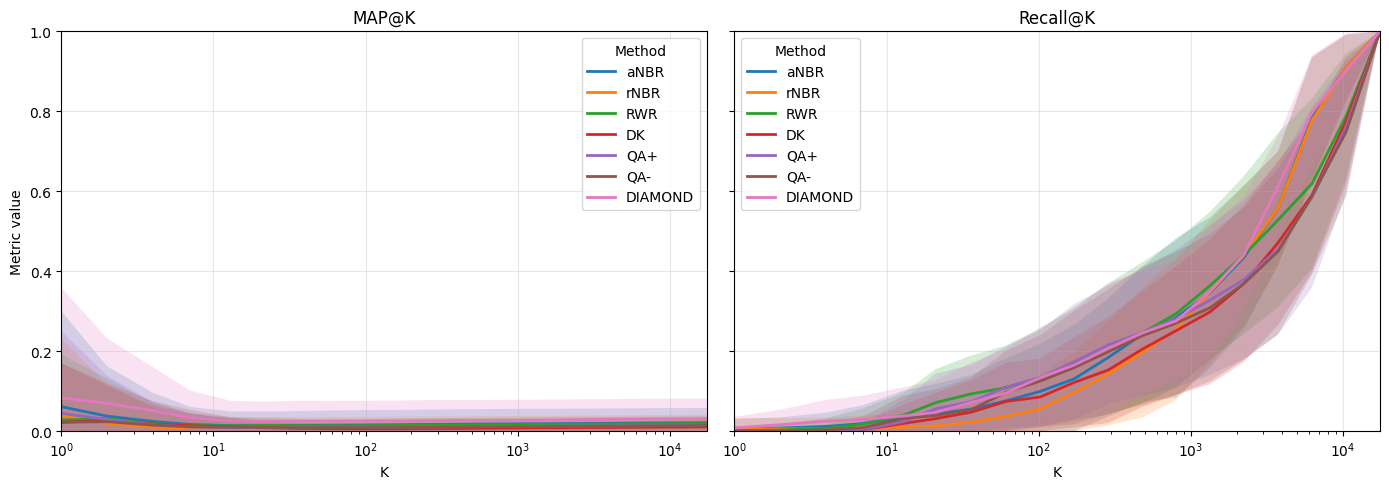

In [41]:
# Build MAP@K and Recall@K curves from the loaded benchmark runs.
k_values_curve = np.unique(np.geomspace(1, len(nodelist), 20).astype(int))
results = {"k_values": k_values_curve, "by_method": {}}

for method_name in method_set:
    ap_runs = np.zeros((len(runs), len(k_values_curve)), dtype=float)
    recall_runs = np.zeros_like(ap_runs)
    for run_index, row in enumerate(runs):
        ranking = scores_to_ranking(
            row["scores"][method_name], nodelist, Ggen, row["train_genes"]
        )
        for k_index, k_eval in enumerate(k_values_curve):
            ap_runs[run_index, k_index] = average_precision_at_k(
                ranking, row["test_genes"], k=int(k_eval)
            )
            recall_runs[run_index, k_index] = recall_at_k(
                ranking, row["test_genes"], k=int(k_eval)
            )
    results["by_method"][method_name] = {
        "ap_mean": ap_runs.mean(axis=0),
        "ap_std": ap_runs.std(axis=0),
        "recall_mean": recall_runs.mean(axis=0),
        "recall_std": recall_runs.std(axis=0),
    }

# Plot MAP@K and Recall@K with +/- 1 std tubes for all methods.
k_vals = results["k_values"]
by_method = results["by_method"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
ax_ap, ax_recall = axes

for method_name, values in by_method.items():
    map_mean = values["ap_mean"]
    map_std = values["ap_std"]
    recall_mean = values["recall_mean"]
    recall_std = values["recall_std"]

    ax_ap.plot(k_vals, map_mean, linewidth=2, label=f"{method_name}")
    ax_ap.fill_between(
        k_vals,
        np.clip(map_mean - map_std, 0.0, 1.0),
        np.clip(map_mean + map_std, 0.0, 1.0),
        alpha=0.2,
    )

    ax_recall.plot(k_vals, recall_mean, linewidth=2, label=f"{method_name}")
    ax_recall.fill_between(
        k_vals,
        np.clip(recall_mean - recall_std, 0.0, 1.0),
        np.clip(recall_mean + recall_std, 0.0, 1.0),
        alpha=0.2,
    )

ax_ap.set_title("MAP@K")
ax_recall.set_title("Recall@K")

for ax in axes:
    ax.set_xlabel("K")
    ax.set_xlim(1, int(k_vals[-1]))
    ax.set_xscale("log")
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", title="Method")

ax_ap.set_ylabel("Metric value")

plt.tight_layout()
plt.show()

In [ ]:
def evaluate_diffusion_over_time(
    disease_name,
    split_fraction,
    num_runs,
    time_values,
    k=20,
    diseases_dict=None,
    graph=None,
    random_seed=None,
):
    """
    Evaluate diffusion ranking over a grid of diffusion times.

    For each run, a new random train/test split is created. For each diffusion
    time t, the diffusion-based ranking is computed from the training genes,
    then AP@k and Recall@k are evaluated against the test genes.

    Parameters
    ----------
    disease_name : str
        Disease key in diseases_dict.
    split_fraction : float
        Fraction of genes used for training in each run.
    num_runs : int
        Number of random seeds / random splits.
    time_values : iterable of float
        Diffusion times to evaluate.
    k : int, optional
        Cutoff for AP@k and Recall@k.
    diseases_dict : dict, optional
        Disease-to-genes mapping. If None, uses global diseases.
    graph : networkx.Graph, optional
        Graph to score on. If None, uses global Ggen.
    random_seed : int, optional
        Base seed for reproducible repeated runs.

    Returns
    -------
    results : dict
        Contains time_values, ap_runs, recall_runs, ap_mean, ap_std,
        recall_mean, recall_std.
    """
    if diseases_dict is None:
        diseases_dict = diseases
    if graph is None:
        graph = Ggen

    time_values = np.asarray(list(time_values), dtype=float)
    if time_values.ndim != 1 or time_values.size == 0:
        raise ValueError("time_values must be a non-empty 1D iterable.")
    if num_runs <= 0:
        raise ValueError("num_runs must be a positive integer.")
    if k <= 0:
        raise ValueError("k must be a positive integer.")
    if disease_name not in diseases_dict:
        raise ValueError(f"Disease '{disease_name}' not found.")

    ap_runs = np.zeros((num_runs, len(time_values)), dtype=float)
    recall_runs = np.zeros((num_runs, len(time_values)), dtype=float)
    nodelist_local = list(graph.nodes())
    laplacian = nx.laplacian_matrix(graph, nodelist=nodelist_local)

    for run_idx in range(num_runs):
        run_seed = None if random_seed is None else random_seed + run_idx
        train_genes, test_genes = split_disease_genes(
            disease_name,
            split_fraction,
            diseases_dict=diseases_dict,
            random_state=run_seed,
        )

        for time_idx, t_value in enumerate(time_values):
            scores = dk_score(
                graph,
                train_genes,
                t=float(t_value),
                L=laplacian,
                nodelist=nodelist_local,
            )
            ranking = scores_to_ranking(
                scores, nodelist_local, graph, train_genes
            )
            ap_runs[run_idx, time_idx] = average_precision_at_k(ranking, test_genes, k=k)
            recall_runs[run_idx, time_idx] = recall_at_k(ranking, test_genes, k=k)

    results = {
        "time_values": time_values,
        "k": k,
        "ap_runs": ap_runs,
        "recall_runs": recall_runs,
        "ap_mean": ap_runs.mean(axis=0),
        "ap_std": ap_runs.std(axis=0),
        "recall_mean": recall_runs.mean(axis=0),
        "recall_std": recall_runs.std(axis=0),
    }
    return results


# Example: diffusion time sweep from 0 to 3 with 20 steps
# Replace num_runs if you want more or fewer random seeds.
diffusion_time_results = evaluate_diffusion_over_time(
    disease_name="breast neoplasms",
    split_fraction=0.75,
    num_runs=50,
    time_values=np.linspace(0.0, 3.0, 20),
    k=20,
    random_seed=42,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
ax_map, ax_recall = axes

t_vals = diffusion_time_results["time_values"]
map_mean = diffusion_time_results["ap_mean"]
map_std = diffusion_time_results["ap_std"]
recall_mean = diffusion_time_results["recall_mean"]
recall_std = diffusion_time_results["recall_std"]

ax_map.plot(t_vals, map_mean, color="tab:blue", linewidth=2, label="Mean MAP@20")
ax_map.fill_between(
    t_vals,
    np.clip(map_mean - map_std, 0.0, 1.0),
    np.clip(map_mean + map_std, 0.0, 1.0),
    color="tab:blue",
    alpha=0.2,
    label="± 1 std",
)
ax_map.set_title("Diffusion MAP@20 vs time")
ax_map.set_xlabel("Diffusion time t")
ax_map.set_ylabel("MAP@20")
ax_map.set_ylim(0, 1.0)
ax_map.grid(True, alpha=0.3)
ax_map.legend(loc="best")

ax_recall.plot(t_vals, recall_mean, color="tab:orange", linewidth=2, label="Mean Recall@20")
ax_recall.fill_between(
    t_vals,
    np.clip(recall_mean - recall_std, 0.0, 1.0),
    np.clip(recall_mean + recall_std, 0.0, 1.0),
    color="tab:orange",
    alpha=0.2,
    label="± 1 std",
)
ax_recall.set_title("Diffusion Recall@20 vs time")
ax_recall.set_xlabel("Diffusion time t")
ax_recall.set_ylabel("Recall@20")
ax_recall.set_ylim(0, 1.0)
ax_recall.grid(True, alpha=0.3)
ax_recall.legend(loc="best")

plt.tight_layout()
plt.show()

In [ ]:
# Legacy duplicate benchmark removed; use the package simulation above.

In [ ]:
# Legacy dense reference implementations were replaced by tests/equivalence.